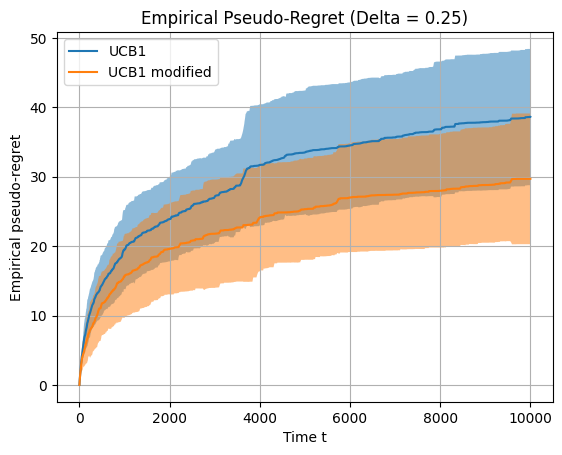

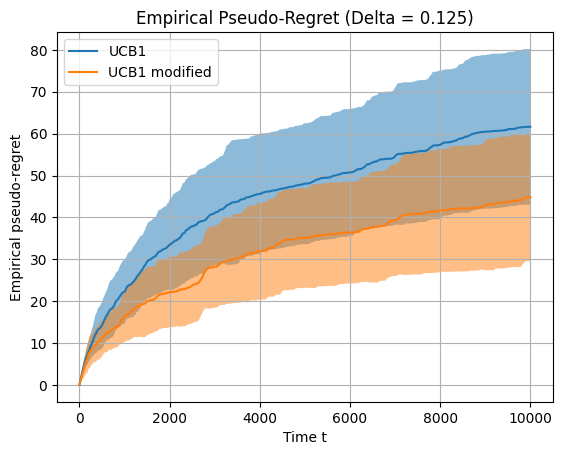

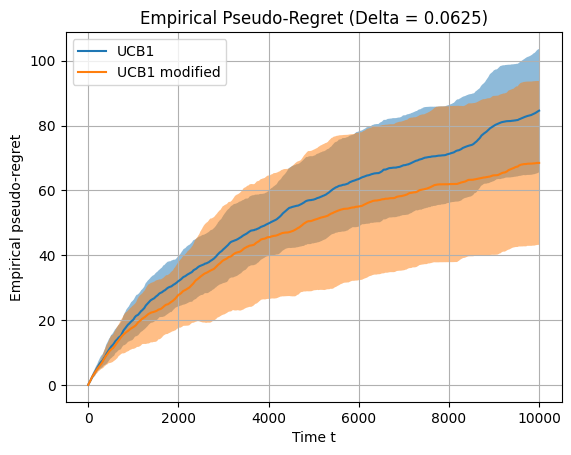

In [3]:
import numpy as np
import matplotlib.pyplot as plt

#UCB1


# 0 is opt, 1 subopt

T = 10000   

def UCB1(T, Delta):
    p_opt = 0.5 + 0.5 * Delta

    p_sub = 0.5 - 0.5 * Delta  
    #cumulative rewards of each arm
    R = np.zeros(2)

    #Number of times played
    N = np.zeros(2)
    # mu(a*)- mu(a) = 0 for A = 0, Delta for A=1
    regret = np.zeros(T)
    #play each action once 
    R[0] += np.random.binomial(1, p_opt)
    N[0] += 1
    R[1] += np.random.binomial(1, p_sub)
    N[1] += 1
    regret[1] = Delta

    # empiric mean
    mu_hat = np.zeros(2)

    mu_hat = R/N
    for t in range(2,T):
        U = mu_hat + np.sqrt(3 * np.log(t) / (2 * N))
        A = np.argmax(U)
        N[A] += 1
        if A == 0:
            R[A] += np.random.binomial(1, p_opt)
        else:
            R[A] += np.random.binomial(1, p_sub)
            regret[t] = Delta
        mu_hat[A] = R[A] / N[A]
    
    return np.cumsum(regret)

def UCB2(T, Delta):
    p_opt = 0.5 + 0.5 * Delta

    p_sub = 0.5 - 0.5 * Delta
    #cumulative rewards of each arm
    R = np.zeros(2)

    #Number of times played
    N = np.zeros(2)
    # mu(a*)- mu(a) = 0 for A = 0, Delta for A=1
    regret = np.zeros(T)
    #play each action once 
    R[0] += np.random.binomial(1, p_opt)
    N[0] += 1
    R[1] += np.random.binomial(1, p_sub)
    N[1] += 1
    regret[1] = Delta

    # empiric mean
    mu_hat = np.zeros(2)

    mu_hat = R/N
    for t in range(2,T):
        U = mu_hat + np.sqrt(np.log(t) / (N))
        A = np.argmax(U)
        N[A] += 1
        if A == 0:
            R[A] += np.random.binomial(1, p_opt)
        else:
            R[A] += np.random.binomial(1, p_sub)
            regret[t] = Delta
        mu_hat[A] = R[A] / N[A]
    
    return np.cumsum(regret)



for Delta in [1/4,1/8,1/16]:
    regrets1 = np.array([UCB1(T,Delta) for _ in range(20)])
    mean1 = regrets1.mean(axis=0)
    std1 = regrets1.std(axis=0)

    regrets2 = np.array([UCB2(T, Delta) for _ in range(20)])
    mean2 = regrets2.mean(axis=0)
    std2 = regrets2.std(axis=0)  

    t = np.arange(1, T + 1)

    plt.plot(t, mean1, label="UCB1")
    plt.fill_between(t, mean1-std1, mean1+std1, alpha = 0.5)

    plt.plot(t, mean2, label="UCB1 modified")
    plt.fill_between(t, mean2-std2, mean2+std2, alpha = 0.5)

    plt.xlabel("Time t")
    plt.ylabel("Empirical pseudo-regret")
    plt.title(f"Empirical Pseudo-Regret (Delta = {Delta})")
    plt.legend()
    plt.grid()
    plt.show()
